In [13]:
import requests
import pandas as pd
import numpy as np

In [14]:
url = "https://api.nbp.pl/api/exchangerates/rates/A/USD/last/100/?format=json"

response = requests.get(url)
data = response.json()

rates = [item["mid"] for item in data["rates"]]

In [18]:
X = []
y = []

window_length = 5

for i in range(len(rates) - window_length):
    X.append(rates[i:i+window_length])
    y.append(rates[i+window_length])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(95, 5)
(95,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
print(X_train.shape)
print(X_test.shape)

(76, 5)
(19, 5)


In [23]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(
    hidden_layer_sizes=(128,),
    max_iter=2000,
    random_state=42
)

model.fit(X_train, y_train)

MLPRegressor(hidden_layer_sizes=(128,), max_iter=2000, random_state=42)

In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE =", mae)
print("RMSE =", rmse)
print("R2 =", r2)

MAE = 0.3781730910593552
RMSE = 0.37897625263735735
R2 = -39.00045967499157


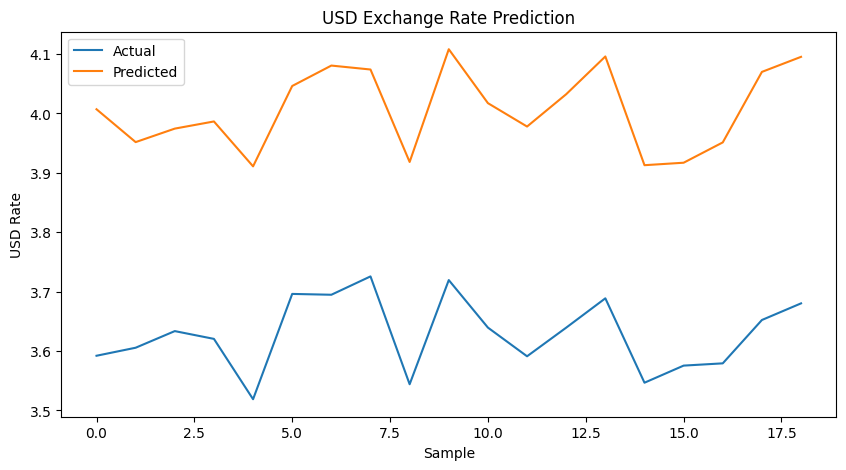

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title("USD Exchange Rate Prediction")
plt.xlabel("Sample")
plt.ylabel("USD Rate")
plt.legend()
plt.show()